# Various Data Tests

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import torch
import faiss
import json
import re
import shutil
import random
from tqdm import tqdm
from torch import Tensor
from dotenv import load_dotenv
from huggingface_hub import login
from torch.utils.data import DataLoader
import torch.nn.functional as F
from scipy.spatial.distance import jensenshannon
from beir.datasets.data_loader import GenericDataLoader
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, logging, AutoModel, AutoModelForCausalLM
logging.set_verbosity_error()
import matplotlib.pyplot as plt

/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco"
train_corpus, train_queries, train_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')
test_corpus, test_queries, test_qrels = GenericDataLoader(data_folder=data_dir).load(split='dev')

100%|██████████| 8841823/8841823 [01:17<00:00, 113637.28it/s]


In [ ]:
test_q = [(q_id, query) for q_id, query in test_queries.items()]
train_q = [(q_id, query) for q_id, query in train_queries.items()]

# Query cosine similarity

In [ ]:
df = pd.read_json("/work/mbouthil/MMATH-CM-Research-Project/RAG/test_results/sim_info.jsonl", lines=True)
df.head()

,train_id,test_id,sim_score
0,1164791,165002,0.802290
1,503515,208145,0.986982
2,1164793,208145,0.965100
3,503515,155234,0.985470
4,1164793,155234,0.976725


In [5]:
print(len(df))

2044


In [6]:
sim_train_queries = [train_queries[str(id)] for id in df['train_id'].tolist()]
sim_test_queries = [test_queries[str(id)] for id in df['test_id'].tolist()]

In [7]:
df['train_query'] = sim_train_queries
df['test_query'] = sim_test_queries

In [8]:
df.head(20)

,train_id,test_id,sim_score,train_query,test_query
0,1164791,165002,0.802290,what causes eyelid itching and swelling,does contraction of the ciliary muscles shorte...
1,503515,208145,0.986982,steering define,how bicycle tire tubes are sized
2,1164793,208145,0.965100,what causes exhaust hanger to fail,how bicycle tire tubes are sized
3,503515,155234,0.985470,steering define,do bigger tires affect gas mileage
4,1164793,155234,0.976725,what causes exhaust hanger to fail,do bigger tires affect gas mileage
5,484187,14151,0.926918,put yourself on child support in texas,age requirements for name change
6,484187,333486,0.710866,put yourself on child support in texas,how old do you have to be to get a job in idaho
7,1164798,73257,0.809404,what causes elevated nitrate levels in aquariums,can seizure meds cause low sodium?
8,597651,85095,0.992110,what color is amber urine,causes for uti in women
9,535936,1101271,0.963996,vde definition,do vhi swiftcare do blood tests?


# Plotting query distributions

## Training and testing query distributions

In [9]:
from collections import Counter
import spacy
nlp = spacy.load("en_core_web_sm")

In [10]:
all_queries = list(train_queries.values()) + list(test_queries.values())

words = set([word
        for query in all_queries
        for word in query.split()])

stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

In [11]:
def tokenize_corpus(corpus, stop_words=None):
    tokens = []
    for doc in corpus:
        for word in doc.split():
            if stop_words and word in stop_words:
                continue
            tokens.append(word.lower())
    return tokens

def relative_freq(tokens):
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w:c/total for w,c in counts.items()}

In [12]:
train_tokens = tokenize_corpus(list(train_queries.values()), stop_words=stop_words)
test_tokens = tokenize_corpus(list(test_queries.values()), stop_words=stop_words)

train_dist = relative_freq(train_tokens)
test_dist = relative_freq(test_tokens)

vocab = sorted(set(train_dist.keys()).union(test_dist.keys()))

In [13]:
from scipy.spatial.distance import jensenshannon

train_vec = np.array([train_dist.get(w,0) for w in vocab])
test_vec = np.array([test_dist.get(w,0) for w in vocab])

js = jensenshannon(train_vec, test_vec)
print("JS divergence:", js)

JS divergence: 0.4231946249684523


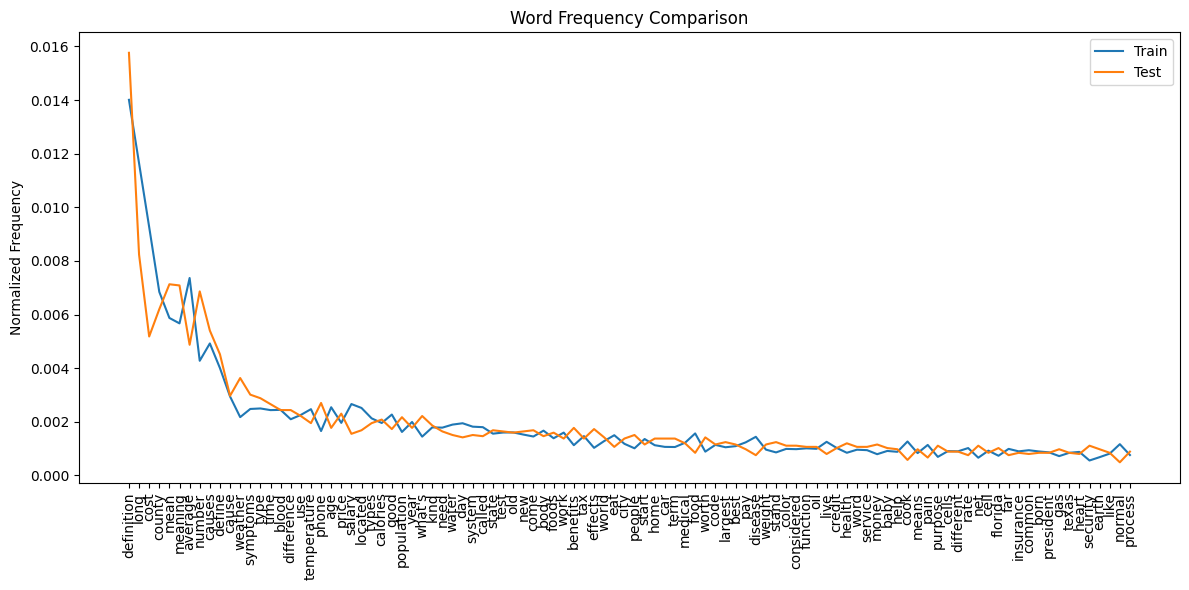

In [14]:
order = np.argsort(train_vec + test_vec)[::-1]
# order = np.argsort(train_vec)[::-1]

K = 100
vocab_sorted = [vocab[i] for i in order[:K]]
train_sorted = train_vec[order][:K]
test_sorted  = test_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, train_sorted, label="Train")
plt.plot(x, test_sorted, label="Test")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
from scipy.spatial.distance import jensenshannon

train_vec = np.array([train_dist.get(w,0) for w in vocab])
test_vec = np.array([test_dist.get(w,0) for w in vocab])

js = jensenshannon(train_vec, test_vec)
print("JS divergence:", js)

NameError: name 'np' is not defined

## Original and synthetic query distributions

In [15]:
# Loading in synthetically enhanced dataset
data_dir = "/work/mbouthil/datasets/msmarco_synq_final"
synq_corpus, synq_queries, synq_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:16<00:00, 115686.46it/s]


In [ ]:
N = len(train_queries)

all_queries = list(synq_queries.values())

words = set([word
        for query in all_queries
        for word in query.split()])

stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

In [19]:
syn_tokens = tokenize_corpus(list(synq_queries.values())[N:], stop_words=stop_words)
orig_tokens = tokenize_corpus(list(test_queries.values())[:N], stop_words=stop_words)

syn_dist = relative_freq(syn_tokens)
orig_dist = relative_freq(orig_tokens)

vocab = sorted(set(syn_dist.keys()).union(orig_dist.keys()))

syn_vec = np.array([syn_dist.get(w,0) for w in vocab])
orig_vec = np.array([orig_dist.get(w,0) for w in vocab])

js = jensenshannon(syn_vec, orig_vec)
print("JS divergence:", js)

JS divergence: 0.5854490375659279


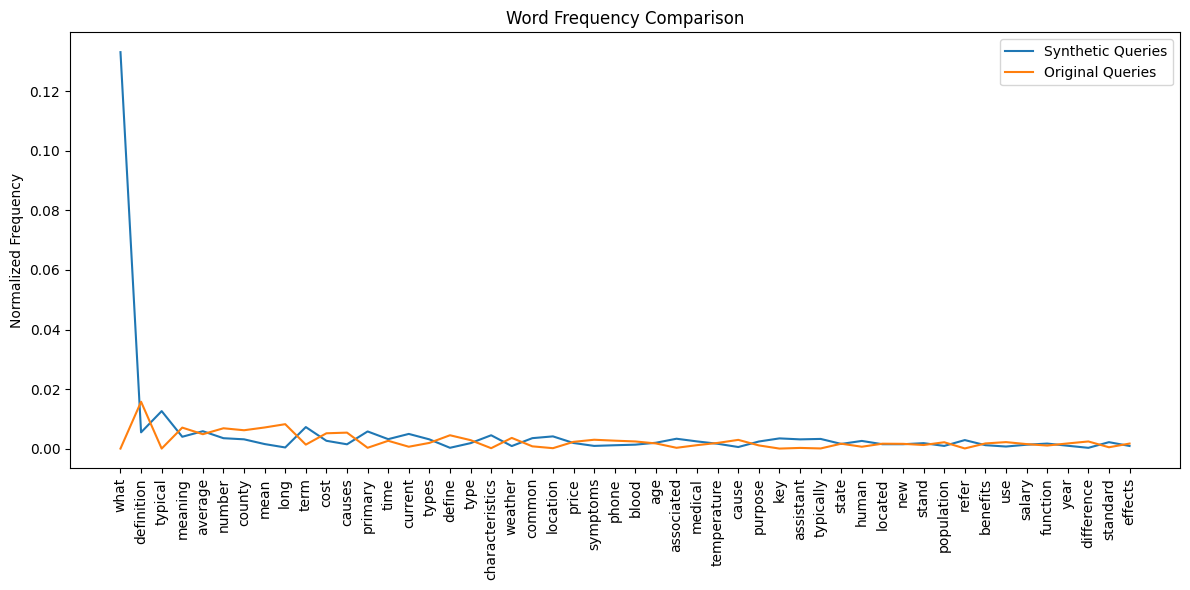

In [22]:
order = np.argsort(syn_vec + orig_vec)[::-1]
# order = np.argsort(train_vec)[::-1]

K = 50
vocab_sorted = [vocab[i] for i in order[:K]]
syn_sorted = syn_vec[order][:K]
orig_sorted  = orig_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, syn_sorted, label="Synthetic Queries")
plt.plot(x, orig_sorted, label="Original Queries")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Various Data Inspection

In [15]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_synq_final"
synq_corpus, synq_queries, synq_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:18<00:00, 113014.25it/s]


In [37]:
print(len(synq_queries))
print(len(train_queries))
print(len(train_queries)-len(synq_queries))

1005878
502939
-502939


In [18]:
keys = [int(key) for key in synq_corpus.keys()]
print(max(keys))
print(min(keys))
print(len(keys))

8841822
0
8841823


In [20]:
with open('/work/mbouthil/datasets/msmarco/corpus.jsonl') as f:
    for i in range(5):
        doc = json.loads(next(f))
        print(doc["_id"])

0
1
2
3
4
